In [2]:
import os 

print(os.getcwd())

os.chdir('E:/GitHubProjects/autolabeling_time_series_data')

from core.generation import *
from core.utils import *

E:\GitHubProjects\autolabeling_time_series_data


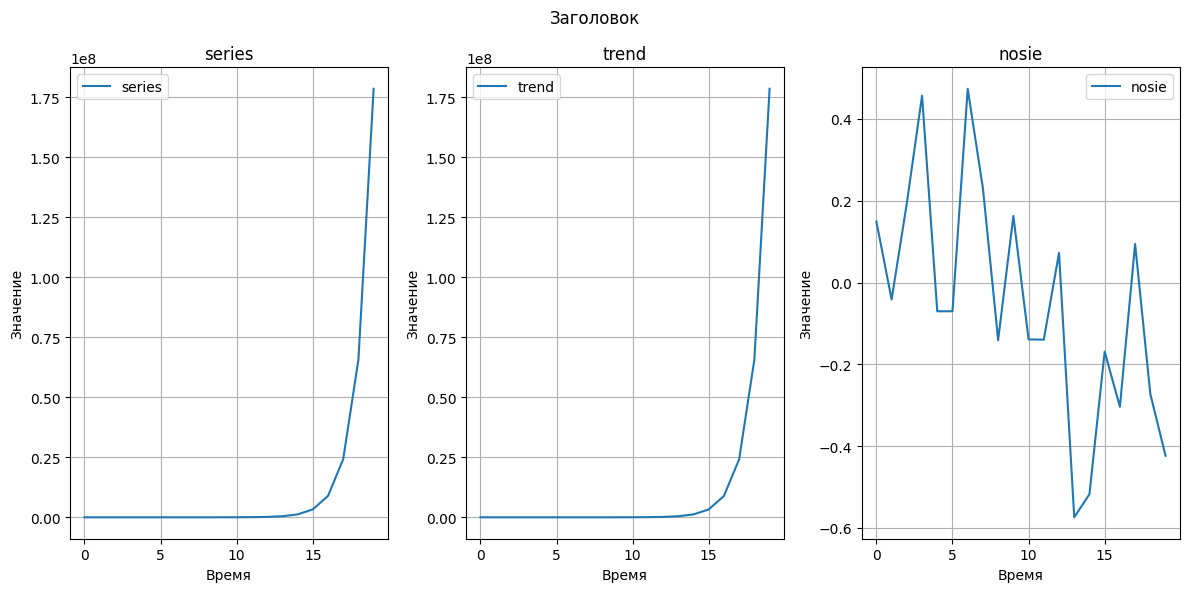

In [4]:
multi_plot_each(exponential_trend(1, 0.3, 20, 42), ['series', 'trend','nosie'])

Generated time series: [ 0.24835708  0.03086785  0.52384427  1.06151493  0.28292331  0.38293152
  1.38960641  1.08371736  0.56526281  1.17128002  0.76829115  0.86713512
  1.32098114  0.34335988  0.53754108  1.21885624  1.09358444  1.85712367
  1.34598796  1.19384815  0.09934283  0.59038113  1.30510821  1.92263996
  1.85528236  1.95317261  2.2179556   1.77152093  1.08167563  0.726546
 -0.09268354 -0.71117994 -1.12717805 -2.00069004 -2.2470966  -2.11245751
 -2.10467926 -1.55518452 -1.35717532 -0.90049473]
Block 1: {'type': 'linear', 'series': array([0.24835708, 0.03086785, 0.52384427, 1.06151493, 0.28292331,
       0.38293152, 1.38960641, 1.08371736, 0.56526281, 1.17128002,
       0.76829115, 0.86713512, 1.32098114, 0.34335988, 0.53754108,
       1.21885624, 1.09358444, 1.85712367, 1.34598796, 1.19384815]), 'params': {'slope': 0.1, 'noise_level': 0.5}, 'random_state': 42}
Block 2: {'type': 'seasonal', 'series': array([ 0.09934283,  0.59038113,  1.30510821,  1.92263996,  1.85528236,
     

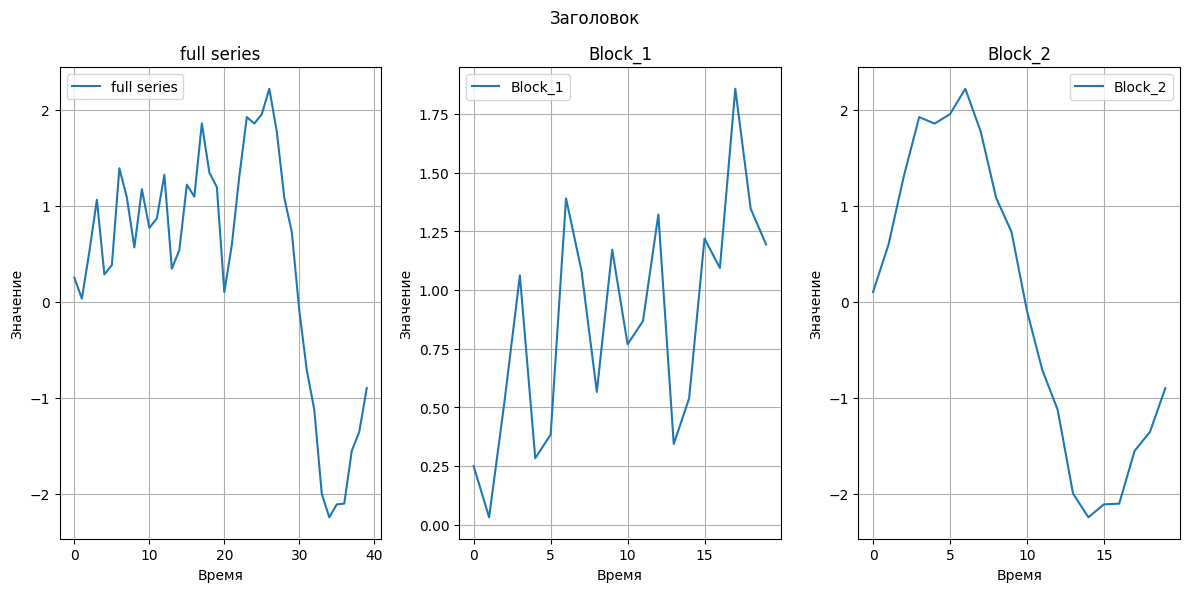

In [5]:
# создаем генератор
generator = Generator()

# добавляем блоки
generator.add_block("linear", length=20, params={"slope": 0.1, "noise_level": 0.5}, random_state=42)
generator.add_block("seasonal", length=20, params={"amplitude": 2.0, "frequency": 1.0, "phase": 0.0, "noise_level": 0.2}, random_state=42)

# список функции для генерации
external_functions = {
    "linear": linear_trend,
    "seasonal": seasonal_series
}

# Генерация временного ряда
time_series, metadata = generator.generate(external_functions)

# Вывод результата
print("Generated time series:", time_series)
for i, block_meta in enumerate(metadata):
    print(f"Block {i+1}: {block_meta}")

multi_plot_each([time_series]+[block_meta['series'] for block_meta in metadata], ['full series']+[f"Block_{i+1}" for i, block_meta in enumerate(metadata)])      